## Глава 9. Прогнозирование непрерывных целевых переменных с помощью регрессионного анализа 

В предыдущих главах вы усвоили основные принципы обучения с учителем и обучили несколько различных классифицирующих моделей прогнозировать принадлежность к группе, или категориальные переменные. В этой главе мы изучим другую разновидность обучения с учителем: регрессионный анализ.

Регрессионные модели применяются для прогнозирования непрерывных целевых переменных, что делает их привлекательными для решения многих научных задач. Они также широко применяются в промышленности - например, для изучения взаимосвязей между переменными, оценки тенденций или составления прогнозов. Одним из примеров является прогнозирование продаж компании на ближайшие месяцы. 

В этой главе мы обсудим основные концепции регрессионных моделей и затронем следующие темы:\
♦ изучение и визуализация наборов данных;\
♦ различные подходы к реализации линейных регрессионных моделей;\
♦ обучение регрессионных моделей, устойчивых к выбросам;\
♦ оценка регрессионных моделей и диагностика распространенных проблем;\
♦ подгонка регрессионных моделей к нелинейным данным. 

### 9.1. Знакомство с линейной регрессией 

Назначение линейной регрессии - смоделировать взаимосвязь между одним или несколькими признаками и непрерывной целевой переменной. В отличие от классификации (другой разновидности обучения с учителем), регрессионный анализ направлен на прогнозирование результатов на непрерывной шкале, а не на категориальных метках классов. В ближайших разделах этой главы вы познакомитесь с основным типом линейной регрессии - простой линейной регрессией и поймете, как связать ее с более общим многомерным случаем (линейная регрессия с несколькими признаками). 

#### 9.1.1. Простая линейная регрессия 

Простая (одномерная) линейная регрессия моделирует взаимосвязь между единственным признаком (независимая переменная, или предиктор х) и целью с непрерывным значением (переменная отклика у). Уравнение линейной модели с одним предиктором выглядит очень просто:
$y = w_l*x + b.$\
Здесь параметр b (смещение, Ьias) представляет точку пересечения оси у, а $w_l$ - весовой коэффициент предиктора. Наша цель - узнать вес и смещение линейного уравнения для описания взаимосвязи между предиктором и целевой переменной, которые затем можно использовать для прогнозирования откликов на новые значения предиктора, которые не были частью обучающего набора данных. Основываясь на линейном уравнении, которое мы определили ранее, линейную регрессию можно рассматривать как поиск наиболее подходящей прямой с помощью обучающих примеров (рис. 9 .1 ). 


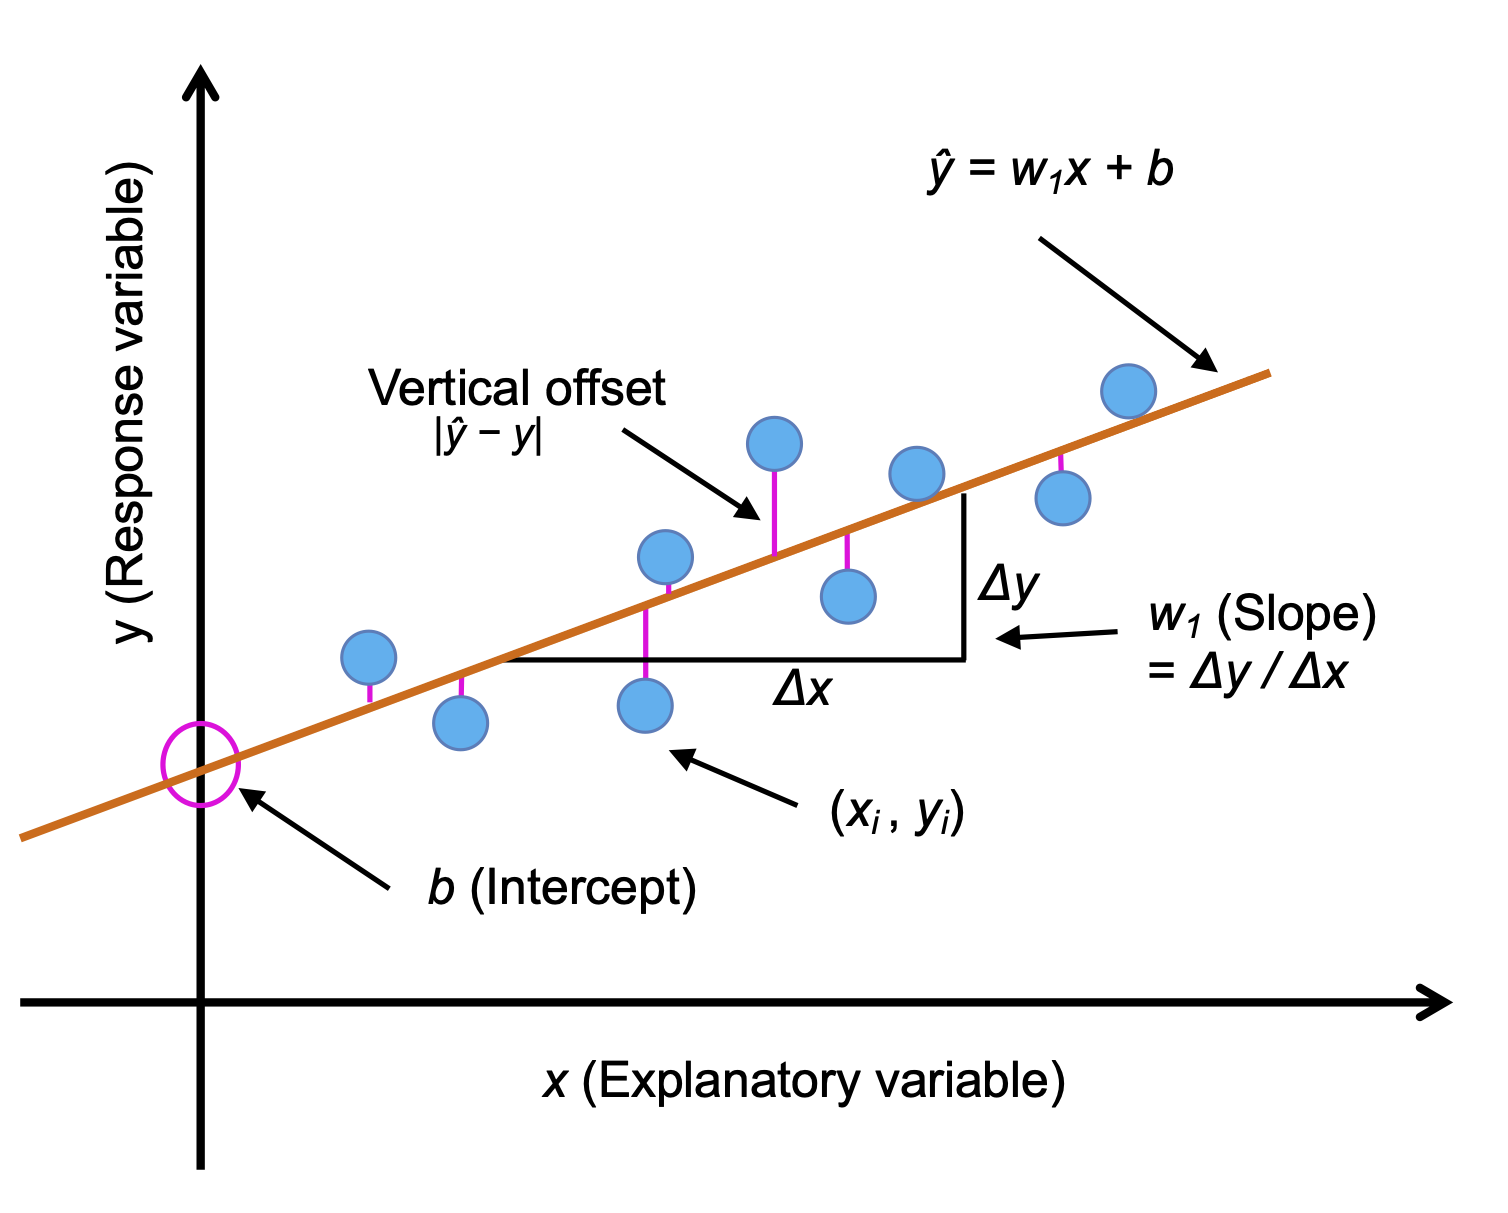

In [ ]:
from IPython.display import Image
Image(filename='figures/09_01.png', width=500) 

Эта наиболее подходящая к данным линия также называется линией регрессии (regression line), а вертикальные отрезки от линии регрессии до обучающих примеров - это так называемые смещения (offset), или остатки (residual), - ошибки нашего прогноза. 

### 9.1.2. Множественная линейная регрессия 

Разумеется, мы также можем обобщить модель линейной регрессии на несколько независимых предикторов - этот процесс
называется многофакторной линейной регрессией (multiple linear regression): 
$y = w_1*x_1 + ... + w_m*x_m = \sum_{i=1}^{m} w_i*x_i + b = w^T + b$

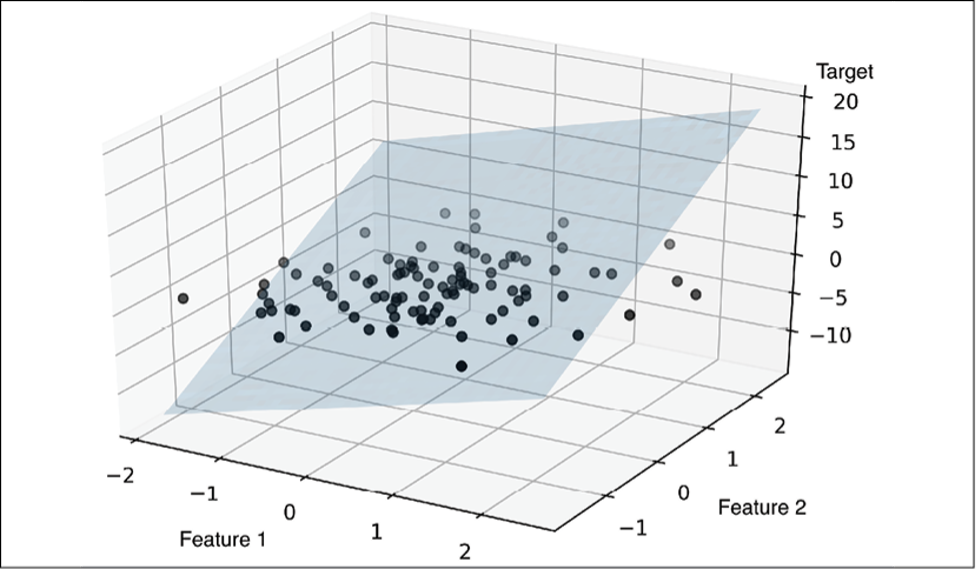

In [3]:
Image(filename='figures/09_01_2.png', width=500) 

Как видите, визуализацию нескольких гиперплоскостей линейной регрессии на трехмерной диаграмме рассеяния уже сложно интерпретировать при взгляде на статическое изображение. Поскольку у нас нет хороших средств визуализации гиперплоскостей с двумя измерениями на диаграмме рассеяния (многофакторные модели линейной регрессии обучают на наборах данных с тремя или более признаками), примеры и визуальные представления в этой главе будут в основном сосредоточены на одномерном случае с использованием простой линейной регрессии. Однако простая и многофакторная линейные регрессии основаны на одних и тех же принципах и одинаковых методах оценки, поэтому реализации кода, которые мы обсудим в этой главе, также совместимы с обоими типами регрессионной модели. 

### 9.2. Изучение набора данных Ames Housing 

#### 9.2.1. Загрузка набора данных Ames Housing в DataFrame 

- `'Overall Qual'`: общая оценка материала и отделки дома по шкале от 1 ( очень плохо) до 10 (отлично);

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
	
- `'Overall Cond'`: общая оценка состояния дома по шкале от 1 ( очень плохо) до 1 (отлично); 

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor
- `'Gr Liv Area'`: жилая площадь над землей в квадратных футах; 
- `'Central Air'`: наличие центрального кондиционера (N=нет, У=да); 
       N	No
       Y	Yes

- `'Total Bsmt SF'`: общая площадь подвала в квадратных футах; 
- `'SalePrice'`: цена продажи в долларах США $. 

In [2]:
import pandas as pd
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
           'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('AmesHousing.txt', sep='\t', usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [5]:
df.shape

(2930, 6)

In [6]:
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

In [7]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [8]:
df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

#### 9.2.2. Визуализация важных характеристик набора данных 

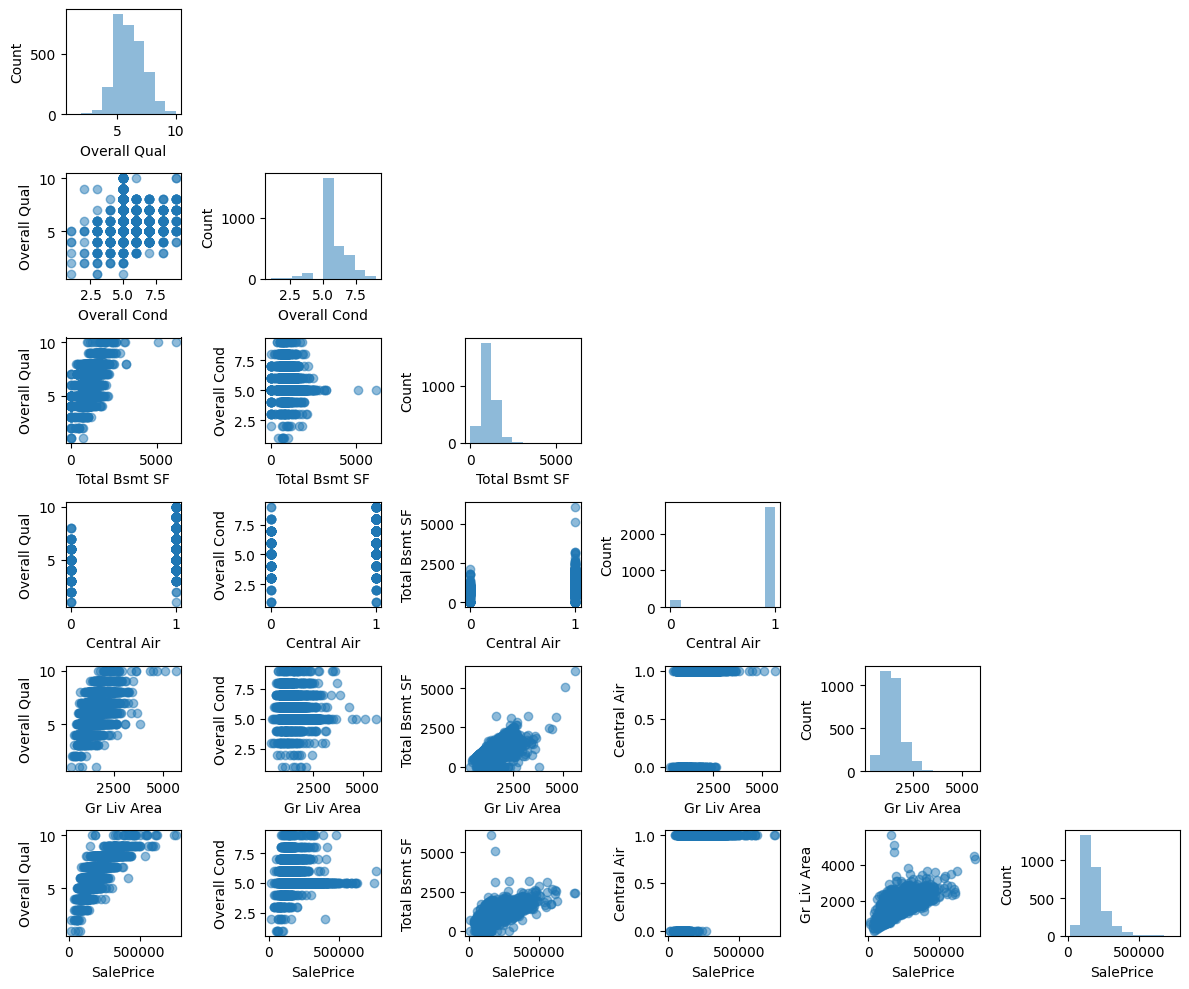

In [9]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix
scatterplotmatrix(df.values, figsize=(12, 10),      names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

#### 9.2.3. Просмотр отношений с помощью матрицы корреляции 

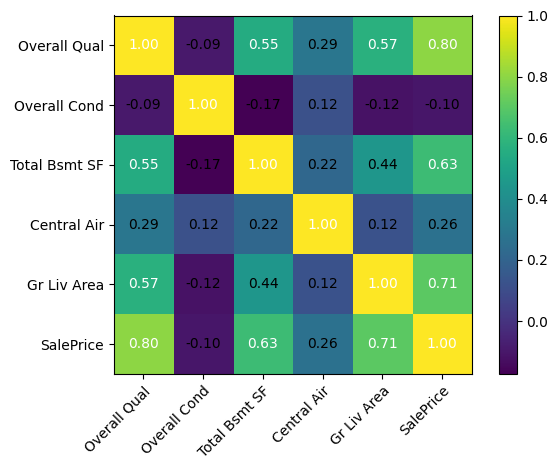

In [10]:
import numpy as np
from mlxtend.plotting import heatmap


cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)

plt.tight_layout()
plt.show()

### 9.3. Реализация обычной модели линейной регрессии методом наименьших квадратов 

В начале этой главы мы упомянули, что обучение линейной регрессии можно рассматривать как построение прямой линии, наиболее точно соответствующей примерам обучающих данных. Однако мы не давали определения термину «наиболее точное соответствие» и не обсуждали различные методы обучения такой модели. Сейчас мы восполним недостающие части этой головоломки, используя обычный метод наименьших квадратов (Ordinary Least Squares, OLS) (иногда также называемый линейным методом наименьших квадратов), чтобы оценить параметры линии линейной регрессии, которая минимизирует сумму квадратов вертикальных расстояний (остатки или ошибки) относительно обучающих примеров.

#### 9.3.1. Нахождение регрессии для параметров регрессии с градиентным спуском 

Мысленно вернемся к нашей реализации адаптивного линейного нейрона (Adaline) из главы 2. Вы помните, что искусственный нейрон использует линейную функцию активации. Кроме того, мы определили функцию потерь L(w), которую минимизировали, чтобы найти веса с помощью алгоритмов оптимизации, таких как градиентный спуск (GD) и стохастический градиентный спуск (SGD). Эта функция потерь в Adaline представляет собой средне1,:вадратичную ошибку (Mean
Squared Error, MSE), идентичную функции потерь, применяемой для OLS:\
$L(w,b) = \frac{1}{2n}\sum_{i=1}^{n} (y^i - \hat{y}^i)^2$\
Здесь $\hat{y}$ прогнозируемое значение $\hat{y}= w^T*х + b$ (множитель 1/2 используется только для удобства получения правила обновления GD). По сути, регрессию по методу OLS можно рассматривать как Adaline без пороговой функции, когда мы получаем непрерывные целевые значения вместо меток класса 0 и 1. Чтобы продемонстрировать это, давайте возьмем реализацию Adaline GD из главы 2 и удалим пороговую функцию, таким образом получив нашу первую модель линейной регрессии: 

In [11]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [12]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()

lr = LinearRegressionGD(eta=0.1)
lr.fit(X_std, y_std)

Обратите внимание на небольшую хитрость при нахождении значения y_std, связанную с использованием np.newaxis и flatten. Большинство классов предварительной обработки данных в scikit-leam предполагают, что данные будут храниться в двумерных массивах. В приведенном примере кода использование метода пр.newaxis в у [: ,пр.newaxis] добавило в массив новое измерение. Затем, после того как standarctscaler вернул масштабированную переменную, мы преобразовали ее для нашего удобства обратно в исходное представление одномерного массива, прибегнув к методу flatten().
В главе 2 мы отметили, что при использовании алгоритмов оптимизации, таких как GD, всегда полезно отображать потери как функцию количества эпох (полных итераций) по набору обучающих данных, чтобы проверить, что алгоритм сошелся к минимуму потерь (здесь глобальный минимум потерь): 

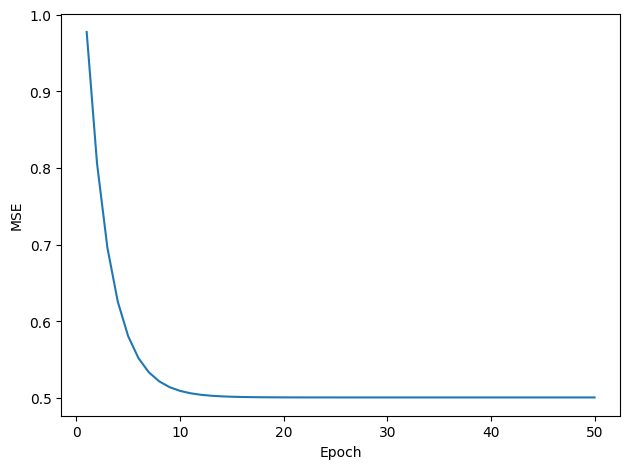

In [13]:
plt.plot(range(1, lr.n_iter+1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

Далее мы выполним визуальную проверку того, насколько хорошо линия линейной регрессии подогнана к обучающим данным. Для этого мы определим простую вспомогательную функцию, которая построит диаграмму рассеивания обучающих примеров и добавит линию регрессии: 

In [14]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)    
    return 

Теперь воспользуемся нашей функцией lin_regplot для построения графика жилой площади в зависимости от цены продажи: 

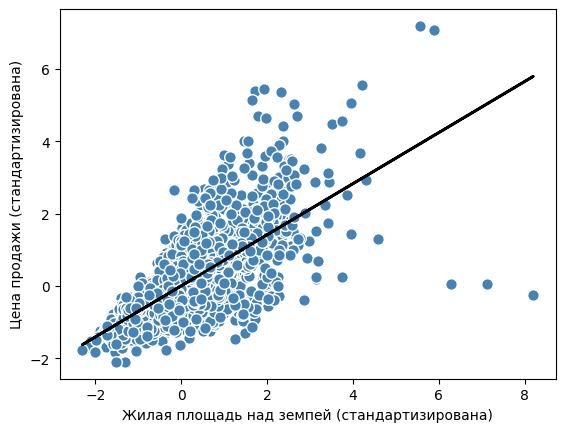

In [15]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Жилая площадь над земпей (стандартизирована)')
plt.ylabel('Цена продажи (стандартизирована)')
plt.show()

В некоторых случаях также может быть важно сообщать прогнозируемые переменные результата в их исходной шкале. Чтобы масштабировать прогнозируемую цену обратно к исходной цене в долларах США, достаточно применить метод inverse_transform класса StandardScaler: 

In [16]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sale price: ${target_reverted.flatten()[0]:.2f}')

Sale price: $292507.07


В качестве примечания также стоит упомянуть, что технически нам не нужно обновлять параметр точки пересечения (например, смещение b), если мы работаем со стандартизированными переменными, поскольку точка пересечения по оси У всегда равна 0 в этих случаях. Мы можем быстро убедиться в этом, выведя параметры модели: 

In [17]:
print(f'Slope: {lr.w_[0]:.3f}')
print(f'Intercept: {lr.b_[0]:.3f}')

Slope: 0.707
Intercept: -0.000


#### 9.3.2. Оценка коэффициента регрессионной модели с помощью scikit-learn 

В предыдущем разделе мы построили работающую модель для регрессионного анализа; однако в реальном приложении нас могут заинтересовать более эффективные реализации. Например, многие оценщики scikit-learn для регрессии используют реализацию метода наименьших квадратов в SciPy (scipy.linalg.lstsq), которая, в свою очередь, основана на высокооптимизированном коде из пакета линейной алгебры (Linear Algebra Package, LAPACK). Реализация линейной регрессии в scikit-leam также работает (и даже лучше) с нестандартизированными переменными, поскольку не использует оптимизацию на основе 
(S)GD, поэтому мы можем пропустить шаг стандартизации: 

In [18]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'Наклон: {slr.coef_[0]:.3f}')
print(f'Пересечение: {slr.intercept_:.3f}')

Наклон: 111.666
Пересечение: 13342.979


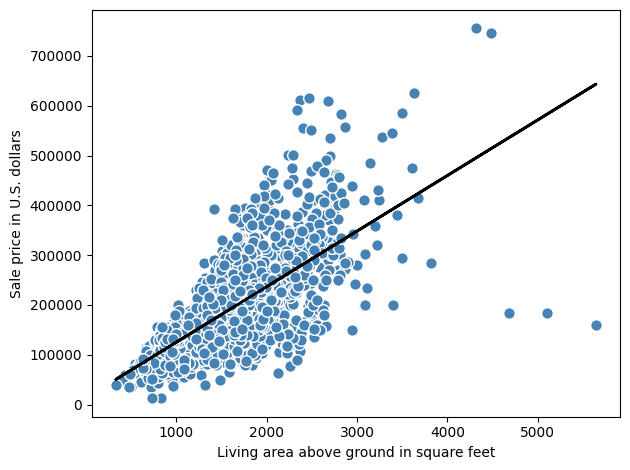

In [19]:
lin_regplot(X, y, slr)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')

plt.tight_layout()
plt.show()

**Normal Equations** alternative:

In [20]:
# добавляем вектор-столбец из "единиц" 
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
w = np.zeros(X.shape[1])
z = np.linalg.inv(np.dot(Xb.T, Xb))
w = np.dot(z, np.dot(Xb.T, y))

print(f'Slope: {w[1]:.3f}')
print(f'Intercept: {w[0]:.3f}')

Slope: 111.666
Intercept: 13342.979


### 9.4. Обучение устойчивой регрессионной модели с использованием RANSAC 

На модели линейной регрессии может сильно повлиять наличие выбросов. В определенных ситуациях очень ограниченное подмножество данных способно оказать большое влияние на коэффициенты модели. Для обнаружения выбросов можно использовать множество статистических тестов, но их описание выходит за рамки книги. Однако удаление выбросов всегда требует нашего собственного суждения как специалистов по данным, а также наших знаний в предметной области.

В качестве альтернативы удалению выбросов мы рассмотрим метод устойчивой регрессии с использованием алгоритма RANdom SAmple Consensus (RANSAC), который обучает модель регрессии на инлаерах (inlier) 1 - не искаженных выбросами «хороших» примерах.\
Итеративный алгоритм RANSAC можно кратко описать следующим образом:\
1. Выберите случайное количество примеров, которые будут считаться инлаерами,
и обучите на них модель.
2. Протестируйте все остальные точки данных на обученной модели и добавьте к инлаерам те точки, которые попадают в заданный вами допуск.
3. Заново обучите модель, используя все инлаеры.
4. Оцените ошибку обученной модели по сравнению с инлаерами.
5. Завершите алгоритм, если производительность модели соответствует определенному порогу, заданному вами, или если достигнуто предельное количество итераций;\
в противном случае вернитесь к шагу 1. 

In [21]:
from sklearn.linear_model import RANSACRegressor


ransac = RANSACRegressor(LinearRegression(), 
                         max_trials=100, # default
                         min_samples=0.95, 
                         loss='absolute_error', # default
                         residual_threshold=None, # default 
                         random_state=123)
ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

Мы устанавливаем здесь максимальное количество итераций RANSACRegressor равным 100, а также при помощи параметра min_samples=0. 95 задаем минимальное количество случайно выбранных обучающих примеров в размере 95% от исходного набора данных. По умолчанию (через параметр residual_threshold=None) scikit-leam использует оценку MAD для выбора порогового значения, где MAD означает медианное абсолютное отклонение (Median Absolute Deviation) целевых значений у. Однако выбор подходящего значения порога инлаера зависит от конкретной задачи, что является одним из недостатков RANSAC.
Теперь давайте получим инлаеры и аутлаеры с помощью только что обученной модели линейной регрессии RANSAC и построим их вместе с линейной регрессией: 

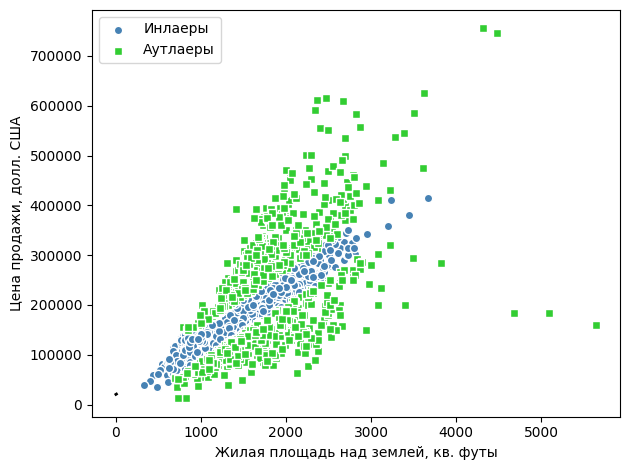

In [22]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])
plt.scatter(X[inlier_mask], y[inlier_mask],
            c='steelblue', edgecolor='white', 
            marker='o', label='Инлаеры')
plt.scatter(X[outlier_mask], y[outlier_mask],
            c='limegreen', edgecolor='white', 
            marker='s', label='Аутлаеры')
plt.plot(line_X, line_y_ransac, color='black', lw=2)   
plt.xlabel('Жилая площадь над землей, кв. футы')
plt.ylabel('Цена продажи, долл. США')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Как показано на рис. 9.9, модель линейной регрессии была обучена на подобранном подмножестве инлаеров (обозначены кружками).
Если мы выведем на экран наклон и точку пересечения линии регрессии при помощи следующего кода, эта линия будет немного отличаться от той, которую мы получили в предыдущем разделе без использования RANSAC: 

In [23]:
print(f'Slope: {ransac.estimator_.coef_[0]:.3f}')
print(f'Intercept: {ransac.estimator_.intercept_:.3f}')

Slope: 106.348
Intercept: 20190.093


Как вы помните, мы установили для параметра residual_threshold значение None, поэтому для вычисления порога между инлаерами и аутлаерами RANSAC использовал МАD. Для этого набора данных MAD можно рассчитать следующим образом: 

In [24]:
def median_absolute_deviation(data):
    return np.median(np.abs(data - np.median(data)))
    
median_absolute_deviation(y)

np.float64(37000.0)

Следовательно, если мы хотим пометить как выбросы меньшее количество точек, необходимо выбрать значение residual_threshold больше, чем предыдущее МАD. Например, на рис. 9.10 показаны инлаеры и аутлаеры модели линейной регрессии RANSAC с residual threshold = 65000. 

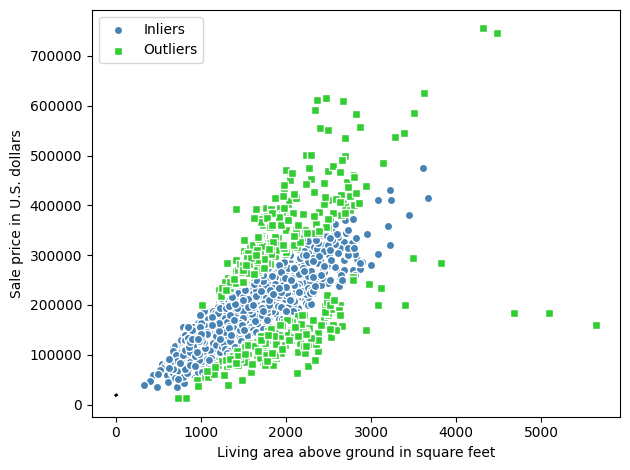

In [25]:
ransac = RANSACRegressor(LinearRegression(), 
                         max_trials=100, # default
                         min_samples=0.95, 
                         loss='absolute_error', # default
                         residual_threshold=65000, # default 
                         random_state=123)

ransac.fit(X, y)

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])
plt.scatter(X[inlier_mask], y[inlier_mask],
            c='steelblue', edgecolor='white', 
            marker='o', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask],
            c='limegreen', edgecolor='white', 
            marker='s', label='Outliers')
plt.plot(line_X, line_y_ransac, color='black', lw=2)   
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [26]:
print(f'Slope: {ransac.estimator_.coef_[0]:.3f}')
print(f'Intercept: {ransac.estimator_.intercept_:.3f}')

Slope: 105.631
Intercept: 18314.587


Используя RANSAC, мы уменьшили потенциальное влияние выбросов, встречающихся в нашем наборе данных, но пока не знаем, улучшит ли этот метод прогностическую эффективность модели на новых данных или нет. Поэтому в следующем разделе мы рассмотрим различные способы получения оценки регрессионной модели, которая является важной частью построения систем для прогнозного моделирования. 

### 9.5. Оценка производительности моделей линейной регрессии 

В предыдущем разделе вы научились обучать регрессионную модель. Однако из рассмотренного ранее материала вы знаете, что крайне важно протестировать модель на данных, которые она не видела во время обучения, чтобы получить более объективную оценку ее обобщающей способности.
Возможно, вы помните из главы 6, что для проверки нужно заранее разделить набор данных на обучающий и тестовый наборы, а затем использовать первый для обучения модели, а второй - для оценки ее обобщающей способности на незнакомых данных. Но вместо того, чтобы ограничиться простой регрессионной моделью, теперь мы будем использовать все пять признаков в наборе данных и обучать модель множественной регрессии: 

In [27]:
from sklearn.model_selection import train_test_split

target = 'SalePrice'
features = df.columns[df.columns != target]

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123)

slr = LinearRegression()
slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

Поскольку в нашей модели используется несколько независимых переменных, мы не можем визуализировать линию линейной регрессии (или, точнее, гиперплоскость) на двумерном графике, но вполне способны построить остаточные значения (разности, или расстояния по вертикали между фактическими и прогнозируемыми значениями) относительно прогнозируемых значений для диагностики нашей регрессионной модели. Графики остатков (residual plot) - широко используемый графический инструмент для диагностики регрессионных моделей. Они помогают обнаружить нелинейность и выбросы, а также проверить, распределены ли ошибки случайным образом. Выполнив следующий код, мы построим график остатков, для чего просто вычтем истинные целевые переменные из наших прогнозов: 

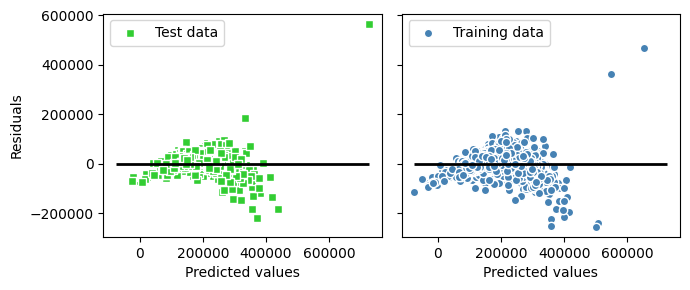

In [28]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Training data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='black', lw=2)

plt.tight_layout()

#plt.savefig('figures/09_11.png', dpi=300)
plt.show()

В случае идеального предсказания остатки были бы строго нулевыми, с чем мы, вероятно, никогда не столкнемся в реальных приложениях. Однако от хорошей модели регрессии мы ожидаем, что ошибки будут распределены случайным образом, а остатки - так же случайным образом разбросаны по центральной линии. Если мы видим на графике остатков какие-то закономерности, это означает, что наша модель не смогла извлечь некоторую полезную информацию, которая просочилась в остатки, что в определенной степени можно заметить на приведенном графике. Кроме того, мы также можем использовать остаточные графики для обнаружения выбросов, которые представлены точками с большим отклонением от центральной линии. 

Другой полезной количественной мерой производительности модели является среднеквадратическая ошибка (Mean Squared Error, MSE), которую мы рассматривали ранее как функцию потерь и старались минимизировать, чтобы обучить модель линейной регрессии. Далее предствлена версия MSE без коэффициента масштабирования 1/2, которая часто используется для упрощения производной потерь при градиентном спуске:\
$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$\
Подобно тому как мы это делали при расчете точности прогноза в задаче классификации, мы можем использовать MSE для перекрестной проверки и выбора модели, как было показано в главе 6. Как и точность классификации, MSE принято нормализовать в зависимости от размера выборки n. Это позволяет сравнивать выборки разных размеров (например, в контексте кривых обучения). Давайте вычислим MSE наших прогнозов при обучении и тестировании: 

In [29]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE при обучении: {mse_train:.2f}')
print(f'MSE при тестировании: {mse_test:.2f}')

MSE при обучении: 1497216245.85
MSE при тестировании: 1516565821.00


Здесь видно, что MSE в обучающем наборе данных меньше, чем в тестовом наборе. Это показатель того, что наша модель в рассматриваемом случае немного склонна к переобучению. Заметим, что часто бывает интуитивно более понятно показывать ошибку в исходных единицах измерения (доллар вместо доллара в квадрате), поэтому мы можем выбрать вычисление квадратного корня из MSE, получив среднеквадратичную ошибку, или среднюю абсолютную ошибку (Mean Absolute Error, МАЕ), которая немного меньше подчеркивает неправильный прогноз:\
$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$

In [30]:
from sklearn.metrics import mean_absolute_error
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE при обучении: {mae_train:.2f}')
print(f'MAE при тестировании: {mae_test:.2f}')

MAE при обучении: 25983.03
MAE при тестировании: 24921.29


Поэтому иногда для лучшей интерпретируемости работы модели бывает полезнее узнать коэффициент смешанной корреляции (coefficient of determination, $R^2$), который можно рассматривать как стандартизированную версию MSE. Или, другими словами, $R^2$ - это доля дисперсии отклика, которая отражена моделью. Значение К определяется так:\
$R^2 = 1 - \frac{SSE}{SST}$\
Здесь SSE представляет собой сумму квадратов ошибок, которая аналогична MSE, но не включает нормализацию по размеру выборки n\
А SST - это сумма квадратов\

Для обучающего набора данных $R^2$ находится в пределах от 0 до 1, но может стать отрицательным для тестового набора данных. Отрицательное значение $R^2$ означает, что регрессионная модель соответствует данным хуже, чем горизонтальная линия, представляющая среднее значение выборки. (На практике это часто происходит в случае экстремального переобучения, или когда мы забываем масштабировать тестовый набор так же, как масштабировали обучающий набор.) Если $R^2$ = 1, модель идеально соответствует данным, и MSE = 0. На обучающих данных $R^2$ нашей модели составляет 0.77, что не идеально, но и не так уж плохо, учитывая, что мы работаем только с небольшим набором признаков. Однако $R^2$ на тестовом наборе данных немного меньше (0.75), что указывает на небольшое переобучение: 

In [31]:
from sklearn.metrics import r2_score


r2_train = r2_score(y_train, y_train_pred)
r2_test =r2_score(y_test, y_test_pred)
print(f'R^2 при обучении: {r2_train:.2f}')
print(f'R^2 при тестировании: {r2_test:.2f}')

R^2 при обучении: 0.77
R^2 при тестировании: 0.75


### 9.6. Использование методов регуляризации для регрессии 

Как было сказано в главе 3, регуляризация - это один из способов решения проблемы переобучения путем добавления дополнительной информации и, таким образом, уменьшения значений параметров модели, чтобы внести штраф за сложность. Наиболее популярными методами регуляризации линейной регрессии являются так называемая гребневая регрессия (ridge regression, ридж-регрессия), LASSO и эластичная сеть. Гребневая регрессия - это модель со штрафом L2, в которой мы просто добавляем квадрат суммы весов к функции потерь MSE:\
$L(w)_{Ridge} = \sum_{i=1}^{n} (y^i - \hat{y}^i )^2 + \lambda||w||^2_2$\
Здесь член L2 определяется следующим образом:\
$\lambda||w||^2_2 = \lambda \sum_{j=1}^{m} w^2_j$\

Увеличивая значение гиперпараметра $\lambda$, мы увеличиваем силу регуляризации и тем самым уменьшаем веса нашей модели. Обратите внимание, что, как упоминалось в главе 3, смещение Ь не регуляризовано. Альтернативным подходом, который может привести к разреженным моделям, является метод LASSO. В зависимости от силы регуляризации, некоторые веса могут стать равными нулю, что также делает LASSO полезным в качестве метода управляемого
отбора признаков:\
$L(w)_{LASSO} = \sum_{i=1}^{n} (y^i - \hat{y}^i )^2 + \lambda||w||_1$\ 
Штраф L1 для LASSO определяется как сумма абсолютных величин весов модели следующим образом:\
$\lambda||w||_1 = \lambda \sum_{j=1}^{m} |w_j|$\
Однако ограничение применимости LASSO заключается в том, что он выбирает не более n признаков, если m > n, где n - количество обучающих примеров. Это может быть нежелательно в некоторых приложениях выбора признаков. Однако на практике это свойство LASSO часто является преимуществом, поскольку позволяет избежать насыщения моделей. Насыщение модели (saturation of model) происходит, если количество обучающих примеров равно количеству признаков, что является формой чрезмерной параметризации. Как следствие, насыщенная модель всегда может идеально соответствовать обучающим данным, но представляет собой лишь вариант интерполяции, и от нее нельзя ожидать хорошего обобщения.\

Компромиссом между гребневой регрессией и LASSO является эластичная сеть, которая имеет как штраф L1 для создания разреженности, так и штраф L2, поэтому ее можно использовать для отбора более чем n признаков, если m > n:\
$L(w)_{Elastic Net} = \sum_{i=1}^{n} (y^i - \hat{y}^i )^2 + \lambda_2||w||^2_2 + \lambda_1||w||_1$\

Все эти регуляризованные регрессионные модели доступны в библиотеке scikit-leam, и их использование аналогично обычной регрессионной модели, за исключением того,что мы должны указать силу регуляризации с помощью параметра $\lambda$, например, оптимизированного с помощью k-кратной перекрестной проверки. Модель гребневой регрессии можно инициализировать с помощью следующего кода: 

In [32]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)
print(lasso.coef_)

[26251.38276394   804.70816337    41.94651964 11364.80761309
    55.67855548]


In [33]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {train_mse:.3f}, test: {test_mse:.3f}')

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f'R^2 train: {train_r2:.3f}, {test_r2:.3f}')

MSE train: 1497216262.014, test: 1516576825.348
R^2 train: 0.769, 0.752


Ridge regression:

In [34]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)

LASSO regression:

In [35]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)

Elastic Net regression:

In [36]:
from sklearn.linear_model import ElasticNet
elanet = ElasticNet(alpha=1.0, l1_ratio=0.5)

### 9.7. Переход от прямой линии к кривой: полиномиальная регрессия 

Ранее мы предполагали линейную зависимость между независимыми переменными и переменными отклика. Один из способов объяснить нарушение предположения о линейности - использовать модель полиномиальной регрессии, добавив полиномиальные члены:\
$y = w_1*x + w_2*x^2 + ... + w_d*x^d + b$\
Здесь d обозначает степень многочлена. Хотя мы можем использовать полиномиальную регрессию для моделирования нелинейной зависимости, ее по-прежнему относят к моделям множественной линейной регрессии из-за коэффициентов линейной регрессии w. Далее вы узнаете о добавлении таких полиномиальных членов в существующий набор данных и обучении модели полиномиальной регрессии. 

#### 9.7.1. Добавление полиномиальных членов с помощью scikit-learn 

Давайте воспользуемся классом преобразователя PolynomialFeatures из библиотеки scikitlearn, чтобы добавить квадратичный член (d = 2) к простой задаче регрессии с одной независимой переменной. Затем сравним полиномиальную модель с линейной, выполнив следующие шаги:
1. Добавим полиномиальный член второй степени:  

In [37]:
X = np.array([258.0, 270.0, 294.0, 
              320.0, 342.0, 368.0, 
              396.0, 446.0, 480.0, 586.0])\
             [:, np.newaxis]

y = np.array([236.4, 234.4, 252.8, 
              298.6, 314.2, 342.2, 
              360.8, 368.0, 391.2,
              390.8])

from sklearn.preprocessing import PolynomialFeatures
lr = LinearRegression()
pr = LinearRegression()
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)

2. Обучим простую модель линейной регрессии для сравнения: 

In [38]:
lr.fit(X, y)
X_fit = np.arange(250, 600, 10)[:, np.newaxis]
y_lin_fit = lr.predict(X_fit)

3. Обучим модель множественной регрессии с преобразованными признаками для полиномиальной регрессии: 

In [39]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(quadratic.fit_transform(X_fit))

4. Отобразим результаты на графике: 

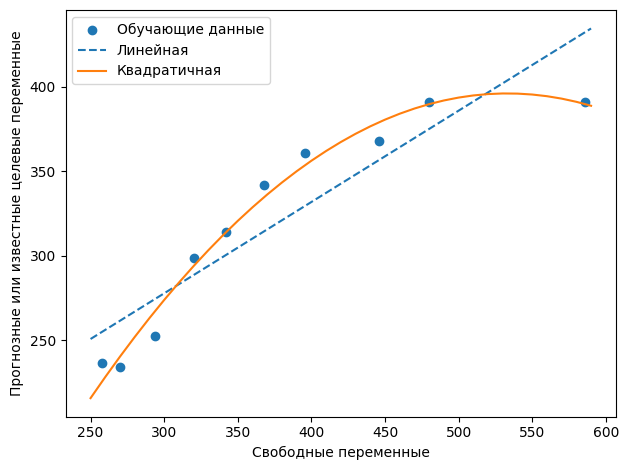

In [40]:
plt.scatter(X, y, label='Обучающие данные')
plt.plot(X_fit, y_lin_fit, label='Линейная', linestyle='--')
plt.plot(X_fit, y_quad_fit, label='Квадратичная')
plt.xlabel('Свободные переменные')
plt.ylabel('Прогнозные или известные целевые переменные')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

На полученном графике (рис. 9.12) отчетливо видно, что полиномиальная аппроксимация отражает связь между откликом и независимыми переменными намного лучше, чем линейная. Далее мы вычислим оценочные метрики MSE и $R^2$: 

In [41]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)

mse_lin = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)
print(f'Обучение MSE, линейная: {mse_lin:.3f}'
      f', квадратичная: {mse_quad:.3f}')

r2_lin = r2_score(y, y_lin_pred)
r2_quad = r2_score(y, y_quad_pred)
print(f'Обучение R^2, линейная: {r2_lin:.3f}'
      f', квадратичная: {r2_quad:.3f}')

Обучение MSE, линейная: 569.780, квадратичная: 61.330
Обучение R^2, линейная: 0.832, квадратичная: 0.982


#### 9.7.2. Моделирование нелинейных отношений в наборе данных Ames Housing 

В предыдущем разделе вы узнали, как создавать полиномиальные признаки, чтобы обучить модель нелинейным отношениям на демонстрационной задаче. Теперь мы рассмотрим более конкретный пример и применим эти методы к данным в наборе Ames Housing. Поэтапно выполняя следующий код, мы смоделируем взаимосвязь между ценой продажи и жилой площадью над землей, используя полиномы второй степени (квадратичные) и третьей степени (кубические), и сравним результаты с линейной моделью.\
А начнем мы с удаления трех выбросов с жилой площадью более 4000 квадратных футов, которые мы видели ранее (например, на рис. 9.8), чтобы эти выбросы не искажали наше регрессионное приближение:  


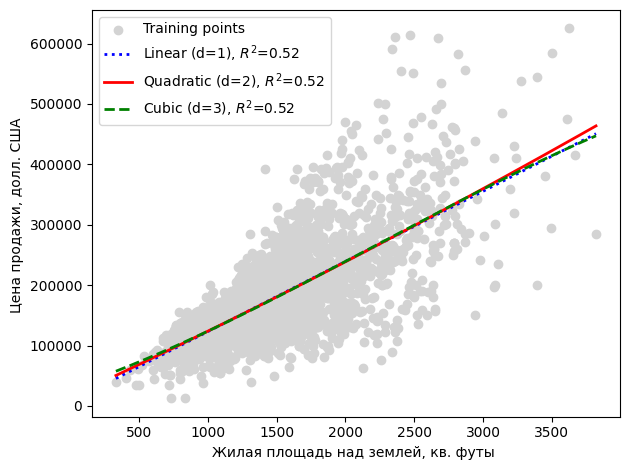

In [42]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
X = X[(df['Gr Liv Area'] < 4000)]
y = y[(df['Gr Liv Area'] < 4000)]
# Теперь обучим регрессионные модели: 
regr = LinearRegression()
# cоздаем квадратичные и кубические признаки 
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)
# обучаем регрессии на признаках 
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))

plt.scatter(X, y, label='Training points', color='lightgray')

plt.plot(X_fit, y_lin_fit, 
         label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue', 
         lw=2, 
         linestyle=':')

plt.plot(X_fit, y_quad_fit, 
         label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red', 
         lw=2,
         linestyle='-')

plt.plot(X_fit, y_cubic_fit, 
         label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green', 
         lw=2,
         linestyle='--')


plt.xlabel('Жилая площадь над землей, кв. футы ')
plt.ylabel('Цeнa продажи, долл. США ')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Очевидно, что использование квадратичных или кубических признаков на самом деле не дает эффекта, поскольку связь между двумя переменными все равно выглядит линейной. Давайте взглянем на другой признак, а именно - на Overall Qual (общее качество). Переменная Overall Qual оценивает общее качество материалов и отделки домов и назначается по шкале от 1 до 10, где 10 - лучший результат: 

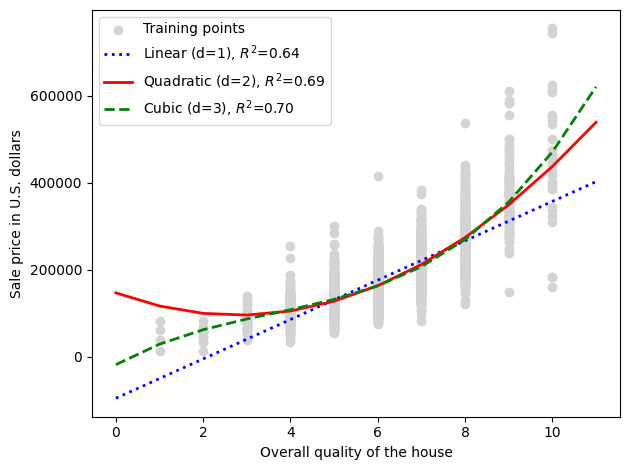

In [43]:
X = df[['Overall Qual']].values
y = df['SalePrice'].values

regr = LinearRegression()
# create quadratic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)
# fit features
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))

plt.scatter(X, y, label='Training points', color='lightgray')

plt.plot(X_fit, y_lin_fit, 
         label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue', 
         lw=2, 
         linestyle=':')

plt.plot(X_fit, y_quad_fit, 
         label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red', 
         lw=2,
         linestyle='-')

plt.plot(X_fit, y_cubic_fit, 
         label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green', 
         lw=2,
         linestyle='--')
plt.xlabel('Overall quality of the house')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Как видите, квадратичная и кубическая аппроксимация лучше отражают взаимосвязь между ценой продажи и общим качеством дома, чем линейная аппроксимация. Однако вы должны учитывать, что добавление большого количества полиномиальных признаков усложняет модель и, следовательно, увеличивает вероятность переобучения. Поэтому на практике всегда рекомендуется проверять производительность модели на отдельном тестовом наборе данных, чтобы оценить качество обобщения. 

### 9.8. Моделирование нелинейных отношений с использованием случайных лесов 

В этом разделе мы рассмотрим регрессию на основе алгоритма случайного леса, которая концептуально отличается от предьщущих моделей регрессии, описанных в этой главе. Случайный лес, который представляет собой ансамбль нескольких деревьев решений, можно рассматривать как сумму кусочно-линейных функций, в отличие от глобальных моделей линейной и полиномиальной регрессии, которые мы обсуждали ранее. Другими словами, с помощью алгоритма дерева решений мы разделяем входное пространство на более мелкие области, которые становятся лучше управляемыми. 

#### 9.8.1. Регрессия на основе алгоритма дерева решений 

Преимущество алгоритма дерева решений заключается в том, что он работает с произвольными признаками и не требует их преобразовывать, если мы имеем дело с нелинейными данными, поскольку деревья решений анализируют один признак за раз, а не рассматривают взвешенные комбинации. (Точно так же для деревьев решений не требуется нормализация или стандартизация признаков.) Как отмечалось в главе 3, мы выращиваем дерево решений, итеративно разбивая его узлы до тех пор, пока листья не станут чистыми, или не будет достигнут критерий остановки. Используя деревья решений для задач классификации, мы определили энтропию как меру примесей, чтобы выяснить, какое разделение признаков максимизирует прирост информации (lnfoпnation Gain, IG)

В главе 3 мы обсуждали примесь Джини и энтропию как меры примеси, которые являются полезными критериями для задач классификации. Однако чтобы использовать дерево решений для регрессии, нам нужна метрика примеси, подходящая для непрерывных переменных, поэтому теперь мы определяем меру примеси узла t как MSE: $I(t) = MSE(t) = \frac{1}{N_t} \sum_{i \in D_t} (y^i - \hat{y_t})^2$\
Здесь $N_t$ - количество обучающих примеров в узле t, $D_t$ - обучающее подмножество в узле t, $y^i$ - истинное целевое значение, а $\hat{y^t}$ - прогнозируемое целевое значение (выборочное среднее):  $\hat{y^t} = \frac{1}{N_t} \sum_{i \in D_t} y^i$\

В контексте регрессии на основе дерева решений MSE часто называют дисперсией внутри узла, поэтому критерий разделения также известен как уменьшение дисперсии. Чтобы увидеть, как выглядит линия регрессии, сформированная деревом решений, воспользуемся реализованным в scikit-learn классом DecisionтreeRegressor и смоделируем взаимосвязь между переменными SalePrice и Gr Living Area. Заметим, что SalePrice и Gr Living Area не обязательно демонстрируют нелинейную связь, но эта комбинация функций все же довольно хорошо иллюстрирует общие аспекты дерева регрессии: 

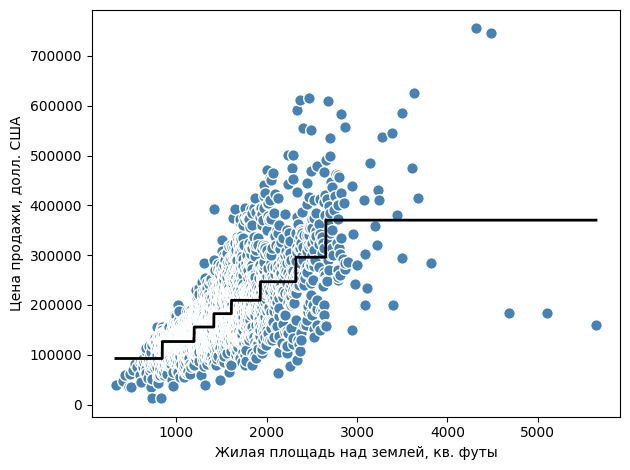

In [60]:
from sklearn.tree import DecisionTreeRegressor
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel('Жилая площадь над землей, кв. футы')
plt.ylabel('Цeнa продажи, долл. США')
plt.tight_layout()
plt.show()

На полученном графике (рис. 9 .15) мы видим, что дерево решений отражает общую тенденцию в данных. Можно предположить, что дерево регрессии также относительно хорошо выявляет тенденции в нелинейных данных. Однако ограничение этой модели заключается в том, что она не отражает непрерывность и дифференцируемость ожидаемого прогноза. Кроме того, нам нужно соблюдать осторожность при выборе подходящего значения глубины дерева, чтобы избежать переобучения или недообучения (в нашем случае глубина 3 оказалась хорошим выбором).

In [61]:
tree_r2 = r2_score(y, tree.predict(X))
tree_r2

0.5144569334885711

#### 9.8.2. Регрессия на основе случайного леса 

Как вы узнали из главы 3, алгоритм случайного леса представляет собой ансамблевый метод, объединяющий несколько деревьев решений. Обобщающая способность случайного леса обычно лучше, чем у отдельного дерева решений, благодаря случайности, которая помогает уменьшить дисперсию модели. Другие преимущества случайных лесов заключаются в том, что они менее чувствительны к выбросам в наборе данных и не нуждаются в кропотливой настройке параметров. Единственный параметр случайного леса, с которым нам обычно приходится экспериментировать, - это количество деревьев в ансамбле. Базовый алгоритм случайного леса для регрессии почти идентичен алгоритму случайного леса для классификации, который мы обсуждали в главе 3.
Единственное отличие состоит в том, что мы используем критерий MSE для выращивания отдельных деревьев решений, а прогнозируемая целевая переменная вычисляется как средний прогноз по всем деревьям решений.

Теперь давайте воспользуемся всеми признаками набора данных Ames Housing, чтобы обучить модель регрессии случайного леса на 70 процентах примеров и оценить ее производительность на оставшихся 30 процентах, как мы сделали ранее в разд. 9.5. Код выглядит следующим образом: 

In [62]:
target = 'SalePrice'
features = df.columns[df.columns != target]

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123)

from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(n_estimators=1000, 
                               criterion='squared_error', 
                               random_state=1, 
                               n_jobs=-1)
forest.fit(X_train, y_train)
y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE train: {mae_train:.2f}')
print(f'MAE test: {mae_test:.2f}')

r2_train = r2_score(y_train, y_train_pred)
r2_test =r2_score(y_test, y_test_pred)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

MAE train: 8305.18
MAE test: 20821.77
R^2 train: 0.98
R^2 test: 0.85


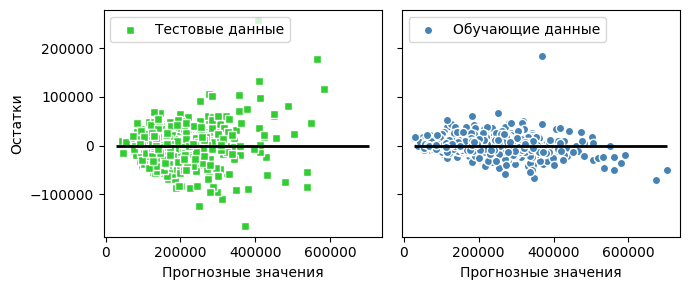

In [64]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Тестовые данные')
ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Обучающие данные')
ax1.set_ylabel('Остатки')

for ax in (ax1, ax2):
    ax.set_xlabel('Прогнозные значения')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='black', lw=2)

plt.tight_layout()
plt.show()

В соответствии с коэффициентом К мы видим, что на тестовых данных модель работает хуже, на что указывают выбросы в направлении оси у. Кроме того, распределение остатков не выглядит полностью случайным вокруг нулевой центральной точки, а это означает, что модель не способна извлечь из данных всю исследовательскую информацию. Однако график остатков (рис. 9.16) демонстрирует значительное улучшение по сравнению с аналогичным графиком линейной модели, который мы построили ранее в этой главе.
В идеале ошибка нашей модели должна быть случайной или непредсказуемой. Другими словами, ошибка прогнозов не должна быть связана ни с какой информацией, содержащейся в независимых переменных, - напротив, она должна отражать случайность реальных распределений. Если мы находим закономерности в ошибках предсказания, просматривая, например, график остатков, это означает, что они содержат прогностическую информацию. Распространенной причиной этого является «просачивание» полезной информации в остатки. К сожалению, универсального подхода для борьбы с закономерностями в графиках остатков не существует, и в каждом новом случае нужны эксперименты. В зависимости от доступных нам данных мы можем улучшить модель, преобразовав переменные, настроив гиперпараметры алгоритма обучения, выбрав более простые или более сложные
модели, удалив выбросы или добавив дополнительные переменные . 

# Заключение 

В начале этой главы вы узнали о простом линейном регрессионном анализе для моделирования взаимосвязи между одной независимой переменной и непрерывной переменной отклика. Затем мы обсудили полезную технику объяснительного анализа для выявления закономерностей и аномалий в данных, что является важным первым шагом в задачах прогнозного моделирования.

Мы построили нашу первую модель, реализовав линейную регрессию с оптимизацией на основе градиента. Затем разобрались, как использовать линейные модели scikit-leam для задач регрессии, а также применять метод устойчивой регрессии (RANSAC) в качестве способа противодействия выбросам в данных. Для оценки прогностической эффективности регрессионных моделей мы вычислили среднюю сумму квадратов ошибок и соответствующую метрику $R^2$ Кроме того, вы освоили полезный графический инструмент для диагностики проблем регрессионных моделей - график остатков.

Изучив применение регуляризации к регрессионным моделям, чтобы уменьшить сложность модели и избежать переобучения, мы затем рассмотрели несколько подходов к моделированию нелинейных отношений, включая полиномиальное представление признаков и регрессоры случайного леса.

В предыдущих главах мы подробно обсуждали обучение с учителем, классификацию и регрессионный анализ. В следующей главе вы узнаете о еще одной интересной области машинного обучения - обучении без учителя, а также о том, как использовать кластерный анализ для поиска скрытых структур в данных при отсутствии целевых переменных. 